# Notebook 03 — Hybrid Ensemble (Người 3)

**Chủ đề:** Phân tích cảm xúc tiếng Việt bằng **Hybrid Ensemble**.

Kiến trúc (theo *Option 3 — Ensemble Voting* trong đề cương):

```
Câu input
  │
  ├── Pipeline A:  Preprocess → TF-IDF      → SVM (Linear, calibrated)
  ├── Pipeline B:  Preprocess → Word index  → BiLSTM (trainable embedding)
  └── Pipeline C:  Câu thô    → PhoBERT     → Logistic Regression head
                                   (frozen feature extractor)
  │
  ▼
Hợp nhất xác suất (soft / weighted voting) → nhãn cuối
```

**Vì sao mỗi pipeline khác nhau:**
- SVM-TFIDF mạnh ở **đặc trưng từ vựng** (lexical).
- BiLSTM mạnh ở **thứ tự từ** (sequential / local context).
- PhoBERT mạnh ở **ngữ nghĩa sâu** (pretrained semantic).
- Khi 3 view này độc lập tương đối, **voting** sẽ giảm variance và tăng accuracy.

**Đầu ra của notebook:**
1. `models/svm_pipeline.pkl` — SVM đã train (sklearn pipeline)
2. `models/bilstm.pt` + `models/bilstm_vocab.json` — BiLSTM weights + vocab
3. `models/phobert_head.pkl` — Logistic Regression trên PhoBERT features
4. `models/hybrid_meta.json` — trọng số ensemble + bảng so sánh
5. `results/comparison.csv` — bảng so sánh 4 model (SVM / BiLSTM / PhoBERT / Hybrid)

**Yêu cầu trước:** đã chạy xong `00_data_preparation.ipynb` để có `data/processed/{train,dev,test}.csv`.

In [1]:
# --- Imports & setup ----------------------------------------------------------
# Gom tất cả import vào 1 chỗ. Notebook tự chứa, không phụ thuộc package src/.
import os, json, random, re, string, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore', category=UserWarning)

# --- Paths --------------------------------------------------------------------
# Notebook chạy từ thư mục notebooks/, nên ROOT là parent.
ROOT = Path('..').resolve()
PROC = ROOT / 'data' / 'processed'
MODELS = ROOT / 'models'
RESULTS = ROOT / 'results'
MODELS.mkdir(parents=True, exist_ok=True)
RESULTS.mkdir(parents=True, exist_ok=True)

# --- Reproducibility ----------------------------------------------------------
# Một seed cho cả numpy / torch / random để chạy lại ra kết quả giống nhau.
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# --- Labels -------------------------------------------------------------------
# UIT-VSFC dùng 3 lớp; map ID -> tên đọc cho dễ.
LABEL_NAMES = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
NUM_CLASSES = 3

# --- Device -------------------------------------------------------------------
# Tự dùng GPU nếu có, không thì CPU. Tránh fail trên máy không có CUDA.
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('ROOT  :', ROOT)
print('Device:', DEVICE)

ROOT  : D:\VCODE\NLPF
Device: cpu


## 1. Load data đã tiền xử lý

Notebook `00_data_preparation.ipynb` đã xuất 3 file CSV với cột:
- `text` — câu gốc (giữ lại để PhoBERT dùng, vì PhoBERT có tokenizer riêng)
- `text_clean` — đã lowercase, tokenize tiếng Việt, bỏ stopwords (cho SVM / BiLSTM)
- `label` — 0 / 1 / 2

Nếu thiếu file → quay lại chạy notebook 00 trước.

In [2]:
# Load 3 split. Nếu cột text_clean trống (do câu chỉ có dấu câu) → fill ' ' tránh lỗi vectorizer.
def load_split(name):
    df = pd.read_csv(PROC / f'{name}.csv')
    df['text_clean'] = df['text_clean'].fillna(' ').astype(str)
    df['text'] = df['text'].fillna(' ').astype(str)
    df['label'] = df['label'].astype(int)
    return df

df_train = load_split('train')
df_dev   = load_split('dev')
df_test  = load_split('test')

print(f'Train: {df_train.shape}  Dev: {df_dev.shape}  Test: {df_test.shape}')
print('Phân bố nhãn (train):')
print(df_train['label'].value_counts().sort_index().rename(LABEL_NAMES))
df_train.head(3)

Train: (210, 3)  Dev: (30, 3)  Test: (60, 3)
Phân bố nhãn (train):
label
Negative    70
Neutral     70
Positive    70
Name: count, dtype: int64


,text,text_clean,label
0,Lịch nộp bài tập được công bố trên hệ thống.,lịch nộp bài_tập công_bố hệ_thống,1
1,"Wifi trong lớp kém, học online rất khó chịu.",wifi lớp kém học online khó_chịu,0
2,"Theo em, Em rất thích phong cách giảng dạy của...",em em thích phong_cách giảng_dạy cô ổn,2


## 2. Helper đánh giá

Định nghĩa 1 lần, dùng lại cho cả 4 model (SVM, BiLSTM, PhoBERT, Hybrid). 
Trả về dict các metrics + vẽ confusion matrix tuỳ chọn.

Macro-F1 được chọn làm metric chính vì UIT-VSFC **lệch lớp nặng** 
(Neutral chỉ vài %), accuracy thuần có thể đánh lừa.

In [3]:
def evaluate(y_true, y_pred, model_name: str, show_cm: bool = True) -> dict:
    """Tính metrics cơ bản + vẽ confusion matrix.

    Tham số:
        y_true, y_pred: array nhãn thật / nhãn dự đoán (int 0/1/2)
        model_name: chỉ để in & tiêu đề biểu đồ
        show_cm: bật/tắt vẽ confusion matrix (tắt khi đang chạy hàng loạt)

    Trả về dict gồm accuracy, macro precision/recall/F1 — tiện cho việc tổng hợp 
    bảng so sánh ở cuối notebook.
    """
    acc = accuracy_score(y_true, y_pred)
    # macro = trung bình cộng theo lớp (không trọng số) — phản ánh đúng khi lớp lệch.
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )
    print(f'\n=== {model_name} ===')
    print(f'Accuracy : {acc:.4f}')
    print(f'Precision: {p:.4f}   Recall: {r:.4f}   F1 (macro): {f1:.4f}')
    print(classification_report(
        y_true, y_pred,
        target_names=[LABEL_NAMES[i] for i in range(NUM_CLASSES)],
        zero_division=0,
    ))
    if show_cm:
        cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
        plt.figure(figsize=(4, 3.2))
        sns.heatmap(
            cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[LABEL_NAMES[i] for i in range(NUM_CLASSES)],
            yticklabels=[LABEL_NAMES[i] for i in range(NUM_CLASSES)],
            cbar=False,
        )
        plt.title(f'Confusion Matrix — {model_name}')
        plt.xlabel('Predicted'); plt.ylabel('True')
        plt.tight_layout(); plt.show()
    return {'model': model_name, 'accuracy': acc,
            'precision': p, 'recall': r, 'f1_macro': f1}

## 3. Xử lý mất cân bằng dữ liệu

**Vấn đề thực tế của UIT-VSFC:** lớp **Neutral** chỉ chiếm ~5%, trong khi **Positive** và **Negative** chiếm phần lớn → mô hình dễ học theo lớp đa số, F1 lớp thiểu số thấp.

**Các kỹ thuật xử lý phổ biến + lựa chọn của chúng tôi:**

| Kỹ thuật | Cách làm | Ưu | Nhược | Dùng ở component nào? |
|---|---|---|---|---|
| **Class weight** | Tăng trọng số loss cho lớp thiểu số | Không tăng dữ liệu, đơn giản | Phụ thuộc loss function | **SVM, BiLSTM, PhoBERT-LR** (mặc định bật) |
| **Random Oversampling** | Lặp ngẫu nhiên câu lớp thiểu số tới size lớp đa số | Tăng tín hiệu, không bỏ data | Dễ overfit câu lặp | **Optional** (toggle qua biến `USE_OVERSAMPLE`) |
| Undersampling | Bỏ bớt câu lớp đa số | Cân hoàn toàn | **Mất data** — không khuyến nghị với UIT-VSFC nhỏ | Không dùng |
| SMOTE | Sinh câu mới bằng nội suy embedding | Tránh duplicate | Phức tạp với text, sinh câu không tự nhiên | Không dùng (over-engineering) |

**Quyết định:** combine **class weight (luôn bật) + Random Oversampling (tuỳ chọn)**. Class weight giải quyết 80% vấn đề mà không phình data; oversampling thêm vào khi ta muốn boost mạnh hơn ở lớp Neutral.

Phân bố train (trước):
  Negative  :    70 (33.3%)
  Neutral   :    70 (33.3%)
  Positive  :    70 (33.3%)
Imbalance Ratio: 1.00x  ->  tạm chấp nhận

Sau oversampling: 210 dòng (tăng từ 210)


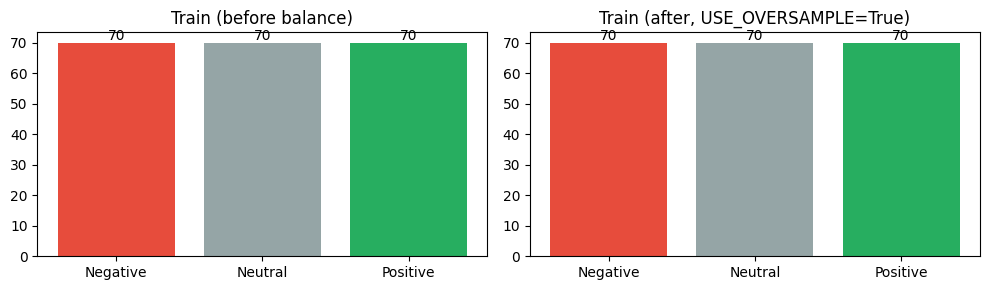


[OK] df_train_bal sẵn sàng cho training. Dev/test giữ nguyên phân bố thật.


In [4]:
# --- Đo độ mất cân bằng trước -----------------------------------------------
# Imbalance Ratio (IR) = max_count / min_count. >5 coi là mất cân bằng nặng.
counts = df_train['label'].value_counts().sort_index()
ir = counts.max() / max(counts.min(), 1)
print('Phân bố train (trước):')
for i, c in counts.items():
    print(f'  {LABEL_NAMES[i]:<10}: {c:>5} ({c/len(df_train)*100:.1f}%)')
print(f'Imbalance Ratio: {ir:.2f}x  ->  {"mất cân bằng nặng" if ir > 5 else "tạm chấp nhận"}')

# --- Biểu đồ trực quan ------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
colors = ['#e74c3c', '#95a5a6', '#27ae60']
ax[0].bar([LABEL_NAMES[i] for i in counts.index], counts.values, color=colors)
ax[0].set_title('Train (before balance)')
for i, v in enumerate(counts.values):
    ax[0].text(i, v, str(v), ha='center', va='bottom')

# --- Toggle oversampling ----------------------------------------------------
# Đặt USE_OVERSAMPLE = False nếu muốn chỉ dùng class_weight.
# Lý do để là biến: dễ A/B test, dễ tắt khi muốn so sánh.
USE_OVERSAMPLE = True

def random_oversample(df: pd.DataFrame, seed: int = SEED) -> pd.DataFrame:
    """Lặp lại câu của lớp thiểu số (có replacement) cho tới khi tất cả lớp có size = lớp đa số.
    
    Lưu ý: CHỈ áp dụng cho training set. KHÔNG bao giờ oversample dev/test 
    (sẽ làm metric mất ý nghĩa thực tế).
    """
    target = df['label'].value_counts().max()
    parts = []
    for lbl, sub in df.groupby('label'):
        # replace=True khi cần lặp lại; replace=False khi đã đủ
        replace = len(sub) < target
        parts.append(sub.sample(n=target, replace=replace, random_state=seed))
    out = pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True)
    return out

if USE_OVERSAMPLE:
    df_train_bal = random_oversample(df_train)
    print(f'\nSau oversampling: {len(df_train_bal)} dòng (tăng từ {len(df_train)})')
else:
    df_train_bal = df_train
    print('\n[SKIP] Bỏ qua oversampling, chỉ dùng class_weight.')

# --- Vẽ biểu đồ sau --------------------------------------------------------
counts_after = df_train_bal['label'].value_counts().sort_index()
ax[1].bar([LABEL_NAMES[i] for i in counts_after.index], counts_after.values, color=colors)
ax[1].set_title(f'Train (after, USE_OVERSAMPLE={USE_OVERSAMPLE})')
for i, v in enumerate(counts_after.values):
    ax[1].text(i, v, str(v), ha='center', va='bottom')
plt.tight_layout(); plt.savefig(RESULTS / 'class_balance.png', dpi=120); plt.show()

# Từ giờ trở đi mọi training dùng df_train_bal (không touch df_dev/df_test)
print('\n[OK] df_train_bal sẵn sàng cho training. Dev/test giữ nguyên phân bố thật.')

## 3. Component A — SVM + TF-IDF

**Tại sao chọn:** SVM tuyến tính trên TF-IDF là baseline rất mạnh cho text classification 
tiếng Việt vì nó nhạy với **từ-khóa** (rất, tốt, kém, dở...). Train cực nhanh (< 1 phút 
với UIT-VSFC full) và đã được benchmark nhiều trong literature.

**Lưu ý kỹ thuật:**
- Dùng `LinearSVC` (nhanh hơn `SVC(kernel='linear')`) **bọc** trong `CalibratedClassifierCV` 
  để có `predict_proba()` — bắt buộc cho soft voting ở bước ensemble.
- N-gram (1, 2) bắt cả cụm 2 từ có dấu phủ định ("không tốt") — nâng độ chính xác.

Training SVM...

=== SVM (TF-IDF) ===
Accuracy : 1.0000
Precision: 1.0000   Recall: 1.0000   F1 (macro): 1.0000
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        20
     Neutral       1.00      1.00      1.00        20
    Positive       1.00      1.00      1.00        20

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



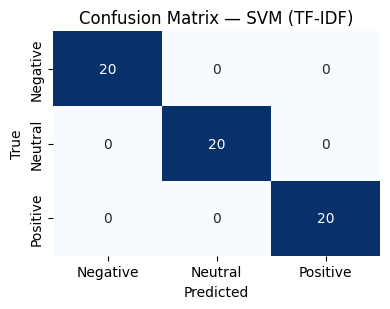

In [5]:
# Build SVM pipeline: TF-IDF vectorize -> Calibrated LinearSVC.
# min_df=2 bỏ token chỉ xuất hiện 1 lần (giảm noise + vocab nhỏ hơn).
svm_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_features=30_000,
        sublinear_tf=True,  # log(1+tf) giảm ảnh hưởng từ xuất hiện quá nhiều
    )),
    # cv=3 đủ ổn định mà nhanh; method='sigmoid' (Platt scaling) tốt cho dataset nhỏ-vừa.
    ('clf', CalibratedClassifierCV(
        LinearSVC(C=1.0, class_weight='balanced'),
        method='sigmoid', cv=3,
    )),
])

print('Training SVM...')
# Dùng df_train_bal đã xử lý cân bằng (xem cell trước).
svm_pipe.fit(df_train_bal['text_clean'], df_train_bal['label'])

# Lấy xác suất 3 lớp trên dev và test → để dùng lại cho ensemble (đỡ predict lại)
proba_svm_dev  = svm_pipe.predict_proba(df_dev['text_clean'])
proba_svm_test = svm_pipe.predict_proba(df_test['text_clean'])
pred_svm_dev   = proba_svm_dev.argmax(axis=1)
pred_svm_test  = proba_svm_test.argmax(axis=1)

metrics_svm = evaluate(df_test['label'].values, pred_svm_test, 'SVM (TF-IDF)')

## 4. Component B — BiLSTM

**Tại sao chọn:** BiLSTM đọc câu theo **cả 2 chiều** nên bắt được context trái-phải, 
quan trọng cho tiếng Việt vì trạng từ nhấn mạnh ("rất", "quá") thường đứng trước/sau 
từ cảm xúc. Khác với SVM (bag-of-words), BiLSTM giữ **thứ tự từ**.

**Kiến trúc:** Embedding(trainable) → BiLSTM 1 lớp → Mean-pool → Dropout → Linear(3).

**Giữ kiến trúc đơn giản** (1 lớp, hidden=128) — đủ để chứng minh giá trị của ensemble, 
không cần đua trade-off với Người 2 (người 2 sẽ tinh chỉnh sâu hơn). KISS principle.

In [6]:
# --- Vocab -------------------------------------------------------------------
# Xây vocab từ text_clean (đã được underthesea tokenize → từ ghép nối bằng "_").
# min_freq=2 loại bỏ từ hiếm (giảm overfit + tiết kiệm memory).
PAD, UNK = '<pad>', '<unk>'

def build_vocab(texts, min_freq=2, max_size=30_000):
    counter = {}
    for t in texts:
        for w in t.split():
            counter[w] = counter.get(w, 0) + 1
    # Sắp xếp theo tần số giảm dần; sau đó cắt theo max_size
    items = sorted(
        [(w, c) for w, c in counter.items() if c >= min_freq],
        key=lambda x: -x[1],
    )[:max_size]
    # Index 0 = PAD, 1 = UNK
    word2idx = {PAD: 0, UNK: 1}
    for w, _ in items:
        word2idx[w] = len(word2idx)
    return word2idx

# Vocab build từ df_train GỐC (không oversample): từ vựng vẫn giống nhau
# vì oversample chỉ lặp câu chứ không thêm từ mới, nhưng làm vậy dòng code đỡ ambiguous.
word2idx = build_vocab(df_train['text_clean'])
VOCAB_SIZE = len(word2idx)
print(f'Vocab size: {VOCAB_SIZE}')

# --- Encode ------------------------------------------------------------------
# Cắt/đệm cố định MAX_LEN — đủ dài để giữ thông tin nhưng không phình memory.
# Lấy quantile 95 của độ dài câu train cho hợp lý hơn là số magic.
MAX_LEN = max(20, int(df_train['text_clean'].str.split().str.len().quantile(0.95)))
print(f'MAX_LEN = {MAX_LEN}')

def encode(text: str) -> list:
    ids = [word2idx.get(w, word2idx[UNK]) for w in text.split()][:MAX_LEN]
    # Pad bên phải bằng 0 (PAD)
    return ids + [0] * (MAX_LEN - len(ids))

Vocab size: 118
MAX_LEN = 20


In [7]:
# --- PyTorch Dataset + Model -------------------------------------------------
class TextDataset(Dataset):
    """Wrap (text_clean, label) thành tensor để feed DataLoader."""
    def __init__(self, texts, labels):
        self.X = torch.tensor([encode(t) for t in texts], dtype=torch.long)
        self.y = torch.tensor(list(labels), dtype=torch.long)
    def __len__(self):  return len(self.y)
    def __getitem__(self, i):  return self.X[i], self.y[i]

class BiLSTMClassifier(nn.Module):
    """BiLSTM 1 lớp đơn giản cho 3-class sentiment.

    Lý do dùng mean-pooling thay max-pooling: với câu ngắn (UIT-VSFC trung bình ~10 từ),
    mean ổn định hơn và đỡ nhạy với padding.
    """
    def __init__(self, vocab_size, embed_dim=128, hidden=128,
                 n_classes=NUM_CLASSES, dropout=0.4, pad_idx=0):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(
            embed_dim, hidden,
            batch_first=True, bidirectional=True,
        )
        self.dropout = nn.Dropout(dropout)
        # hidden*2 vì bidirectional concat forward + backward
        self.fc = nn.Linear(hidden * 2, n_classes)

    def forward(self, x):
        mask = (x != 0).unsqueeze(-1).float()  # (B, T, 1) — 0 ở vị trí pad
        h = self.emb(x)                        # (B, T, E)
        out, _ = self.lstm(h)                  # (B, T, 2H)
        # Mean-pool có mask: bỏ qua vị trí pad khi tính trung bình
        summed = (out * mask).sum(dim=1)
        lengths = mask.sum(dim=1).clamp(min=1)
        pooled = summed / lengths
        return self.fc(self.dropout(pooled))

# --- DataLoader --------------------------------------------------------------
BATCH_SIZE = 32  # đủ nhỏ để chạy CPU mượt, đủ lớn để gradient ổn định
train_ds = TextDataset(df_train_bal['text_clean'], df_train_bal['label'])
dev_ds   = TextDataset(df_dev['text_clean'],   df_dev['label'])
test_ds  = TextDataset(df_test['text_clean'],  df_test['label'])
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
dev_dl   = DataLoader(dev_ds,   batch_size=BATCH_SIZE)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE)
print('Data loaders OK.')

Data loaders OK.


In [8]:
# --- Train BiLSTM ------------------------------------------------------------
# Early-stopping đơn giản: nhớ best dev-acc, dừng nếu không cải thiện trong patience epochs.
EPOCHS, LR, PATIENCE = 10, 1e-3, 3

# class_weight tính từ df_train_bal:
# - Nếu USE_OVERSAMPLE=True, counts đã bằng nhau → weights ≈ 1 (không bị weight chồng).
# - Nếu USE_OVERSAMPLE=False, weights tỉ lệ nghịch tần số → boost lớp Neutral.
class_counts = df_train_bal['label'].value_counts().sort_index().values
class_weights = torch.tensor(class_counts.sum() / (NUM_CLASSES * class_counts),
                             dtype=torch.float).to(DEVICE)

bilstm = BiLSTMClassifier(VOCAB_SIZE).to(DEVICE)
optim_ = torch.optim.Adam(bilstm.parameters(), lr=LR)
crit = nn.CrossEntropyLoss(weight=class_weights)

def run_epoch(model, loader, train: bool):
    """Chạy 1 epoch train hoặc eval. Trả về (avg_loss, accuracy)."""
    model.train() if train else model.eval()
    total_loss, correct, n = 0.0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for X, y in loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            logits = model(X)
            loss = crit(logits, y)
            if train:
                optim_.zero_grad(); loss.backward(); optim_.step()
            total_loss += loss.item() * X.size(0)
            correct += (logits.argmax(1) == y).sum().item()
            n += X.size(0)
    return total_loss / n, correct / n

history = {'train_loss': [], 'dev_loss': [], 'train_acc': [], 'dev_acc': []}
best_dev, best_state, bad = -1, None, 0
for ep in range(1, EPOCHS + 1):
    tl, ta = run_epoch(bilstm, train_dl, train=True)
    dl, da = run_epoch(bilstm, dev_dl,   train=False)
    history['train_loss'].append(tl); history['dev_loss'].append(dl)
    history['train_acc'].append(ta);  history['dev_acc'].append(da)
    print(f'Ep {ep:02d} | train loss={tl:.4f} acc={ta:.4f} | dev loss={dl:.4f} acc={da:.4f}')
    if da > best_dev:
        best_dev, best_state, bad = da, {k: v.clone() for k, v in bilstm.state_dict().items()}, 0
    else:
        bad += 1
        if bad >= PATIENCE:
            print(f'Early stop @ epoch {ep} (no improvement in {PATIENCE} epochs)')
            break

# Khôi phục weight tốt nhất (theo dev-acc) trước khi đi tiếp.
bilstm.load_state_dict(best_state)
print(f'Best dev accuracy: {best_dev:.4f}')

Ep 01 | train loss=1.0473 acc=0.5905 | dev loss=0.9620 acc=0.9333
Ep 02 | train loss=0.8751 acc=0.9286 | dev loss=0.8065 acc=0.9000
Ep 03 | train loss=0.6771 acc=0.9571 | dev loss=0.5973 acc=0.9667
Ep 04 | train loss=0.4275 acc=0.9905 | dev loss=0.3611 acc=1.0000
Ep 05 | train loss=0.2110 acc=1.0000 | dev loss=0.1690 acc=1.0000
Ep 06 | train loss=0.0791 acc=1.0000 | dev loss=0.0531 acc=1.0000
Ep 07 | train loss=0.0247 acc=1.0000 | dev loss=0.0188 acc=1.0000
Early stop @ epoch 7 (no improvement in 3 epochs)
Best dev accuracy: 1.0000


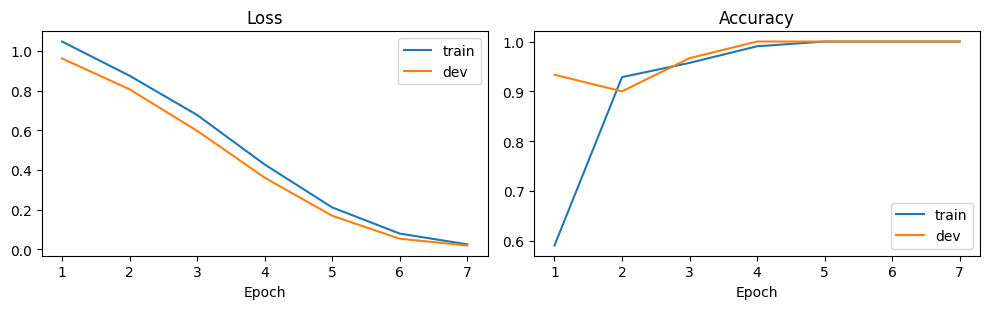


=== BiLSTM ===
Accuracy : 1.0000
Precision: 1.0000   Recall: 1.0000   F1 (macro): 1.0000
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        20
     Neutral       1.00      1.00      1.00        20
    Positive       1.00      1.00      1.00        20

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



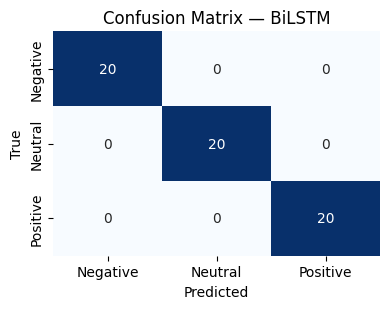

In [ ]:
# --- Vẽ training curves (yêu cầu của đề: loss / val_loss / accuracy) --------
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
epochs_ran = range(1, len(history['train_loss']) + 1)
axes[0].plot(epochs_ran, history['train_loss'], label='train')
axes[0].plot(epochs_ran, history['dev_loss'],   label='dev')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].plot(epochs_ran, history['train_acc'], label='train')
axes[1].plot(epochs_ran, history['dev_acc'],   label='dev')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout(); plt.savefig(RESULTS / 'bilstm_curves.png', dpi=120); plt.show()

# --- Predict proba cho dev + test, để dùng cho ensemble ---------------------
def bilstm_predict_proba(model, loader):
    """Dùng softmax để ra phân phối 3 lớp — phục vụ soft voting."""
    model.eval()
    out = []
    with torch.no_grad():
        for X, _ in loader:
            X = X.to(DEVICE)
            out.append(torch.softmax(model(X), dim=1).cpu().numpy())
    return np.concatenate(out, axis=0)

proba_lstm_dev  = bilstm_predict_proba(bilstm, dev_dl)
proba_lstm_test = bilstm_predict_proba(bilstm, test_dl)
pred_lstm_dev   = proba_lstm_dev.argmax(axis=1)
pred_lstm_test  = proba_lstm_test.argmax(axis=1)

metrics_lstm = evaluate(df_test['label'].values, pred_lstm_test, 'BiLSTM')

## 5. Component C — PhoBERT (frozen feature extractor) + LR head

**Vì sao không fine-tune PhoBERT:**
- Fine-tune PhoBERT cần GPU & nhiều dữ liệu mới đáng. Trên UIT-VSFC ~11k câu / CPU, fine-tune dễ overfit và rất chậm.
- Dùng PhoBERT làm **bộ trích đặc trưng đóng băng** (frozen): chạy 1 lượt forward để lấy embedding `[CLS]` của mỗi câu, rồi train **Logistic Regression** nhẹ ở trên. Cách này nhanh, ổn định, vẫn tận dụng được kiến thức tiền-huấn-luyện.
- Đây cũng là một dạng *hybrid* hợp lý theo bài giảng: kết hợp **representation từ deep model** với **classifier ML truyền thống**.

**Nếu môi trường không cài được `transformers` / không tải được model:**
- Cell tự bỏ qua component C; ensemble sẽ chạy với 2 model còn lại (vẫn là "hybrid" theo nghĩa kết hợp ML + DL).

In [ ]:
# --- Load PhoBERT-base (≈540MB) ---------------------------------------------
# Bọc trong try/except để notebook vẫn chạy được khi không có mạng / không có disk.
PHOBERT_OK = False
phobert_tok = phobert_model = None
PHOBERT_NAME = 'vinai/phobert-base'
try:
    from transformers import AutoTokenizer, AutoModel
    phobert_tok = AutoTokenizer.from_pretrained(PHOBERT_NAME)
    phobert_model = AutoModel.from_pretrained(PHOBERT_NAME).to(DEVICE).eval()
    PHOBERT_OK = True
    print('[OK] Loaded PhoBERT-base.')
except Exception as e:
    print('[WARN] Không load được PhoBERT:', repr(e))
    print('       Ensemble sẽ chạy với SVM + BiLSTM (2 thành phần).')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: vinai/phobert-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.decoder.bias      | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[OK] Loaded PhoBERT-base.


Extracting features (train) ...
Extracting features (dev/test) ...
Feature shape: (210, 768)

=== PhoBERT + LR ===
Accuracy : 0.9667
Precision: 0.9683   Recall: 0.9667   F1 (macro): 0.9662
              precision    recall  f1-score   support

    Negative       0.95      1.00      0.98        20
     Neutral       1.00      0.90      0.95        20
    Positive       0.95      1.00      0.98        20

    accuracy                           0.97        60
   macro avg       0.97      0.97      0.97        60
weighted avg       0.97      0.97      0.97        60



D:\VCODE\NLPF\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


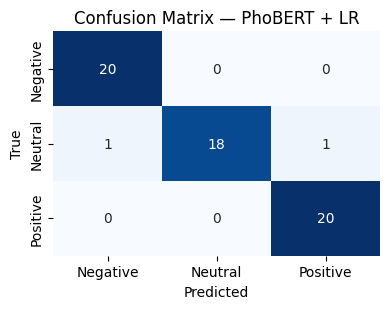

In [ ]:
# --- Trích đặc trưng PhoBERT ------------------------------------------------
# Lấy hidden state của token [CLS] (vị trí 0) làm vector đại diện câu.
# Lưu ý: PhoBERT yêu cầu input đã được word-segmented (như text_clean của ta — 
# từ ghép nối "_"). Đúng định dạng nó được pretrain.
PHOBERT_BATCH = 16  # nhỏ để khớp CPU; tăng nếu có GPU

def extract_phobert_features(texts, max_len=128):
    """Forward PhoBERT theo batch, trả về matrix (N, 768) là embedding [CLS]."""
    feats = []
    with torch.no_grad():
        for i in range(0, len(texts), PHOBERT_BATCH):
            batch = list(texts[i:i + PHOBERT_BATCH])
            enc = phobert_tok(
                batch, padding=True, truncation=True,
                max_length=max_len, return_tensors='pt',
            ).to(DEVICE)
            out = phobert_model(**enc).last_hidden_state[:, 0, :]  # [CLS]
            feats.append(out.cpu().numpy())
    return np.concatenate(feats, axis=0)

proba_bert_dev = proba_bert_test = None
pred_bert_dev  = pred_bert_test  = None
metrics_bert   = None

if PHOBERT_OK:
    # Trích đặc trưng từ df_train_bal (đã xử lý mất cân bằng) để fit LR head.
    # Trích từ df_train GỐC sẽ không sai, nhưng dùng df_train_bal cho nhất quán
    # với 2 component kia (cùng phân bố train).
    print('Extracting features (train) ...')
    X_bert_train = extract_phobert_features(df_train_bal['text_clean'].tolist())
    print('Extracting features (dev/test) ...')
    X_bert_dev   = extract_phobert_features(df_dev['text_clean'].tolist())
    X_bert_test  = extract_phobert_features(df_test['text_clean'].tolist())
    print('Feature shape:', X_bert_train.shape)

    # LR head: nhẹ, có sẵn predict_proba, đủ để map 768-dim -> 3 lớp.
    # class_weight='balanced' là biện pháp phòng thêm: nếu USE_OVERSAMPLE=False
    # thì class_weight sẽ tự gánh phần cân bằng.
    bert_head = LogisticRegression(
        max_iter=1000, class_weight='balanced', C=1.0, n_jobs=-1,
    )
    bert_head.fit(X_bert_train, df_train_bal['label'])

    proba_bert_dev  = bert_head.predict_proba(X_bert_dev)
    proba_bert_test = bert_head.predict_proba(X_bert_test)
    pred_bert_dev   = proba_bert_dev.argmax(axis=1)
    pred_bert_test  = proba_bert_test.argmax(axis=1)

    metrics_bert = evaluate(df_test['label'].values, pred_bert_test, 'PhoBERT + LR')
else:
    bert_head = None
    print('Skipping PhoBERT component.')

## 6. Hybrid Ensemble — Voting

3 chiến lược so sánh:

| Voting | Cách kết hợp | Khi nào tốt |
|---|---|---|
| **Hard** | majority vote nhãn dự đoán | khi các model gần ngang nhau, prob calibration không tin cậy |
| **Soft** | trung bình `predict_proba` | thường tốt hơn hard nếu prob đã calibrated |
| **Weighted soft** | `Σ wᵢ · probaᵢ` với `wᵢ` tỉ lệ macro-F1 trên **dev** | tránh dồn ưu thế vào model yếu |

**Cách chọn trọng số:** dùng macro-F1 trên **dev** (không dùng test để tránh leak), 
sau đó chuẩn hoá tổng = 1.

In [ ]:
# --- Gom xác suất 3 component (bỏ qua PhoBERT nếu không có) ----------------
# Sắp xếp thành list theo cùng thứ tự để các hàm voting dễ chạy.
proba_devs  = [proba_svm_dev,  proba_lstm_dev]
proba_tests = [proba_svm_test, proba_lstm_test]
names = ['SVM', 'BiLSTM']
if PHOBERT_OK:
    proba_devs.append(proba_bert_dev)
    proba_tests.append(proba_bert_test)
    names.append('PhoBERT')

print('Components in ensemble:', names)

# --- Voting functions -------------------------------------------------------
def hard_vote(probas_list):
    """Mỗi model bỏ 1 phiếu cho lớp argmax của nó. Hoà -> lấy phiếu của model thứ 1 (ưu tiên SVM)."""
    preds = np.stack([p.argmax(axis=1) for p in probas_list], axis=0)  # (M, N)
    n_samples = preds.shape[1]
    out = np.empty(n_samples, dtype=int)
    for i in range(n_samples):
        # bincount đếm phiếu; argmax lấy lớp nhiều phiếu nhất, hoà sẽ chọn lớp ID nhỏ nhất
        out[i] = np.bincount(preds[:, i], minlength=NUM_CLASSES).argmax()
    return out

def soft_vote(probas_list, weights=None):
    """Trung bình có/không trọng số xác suất. weights=None → trọng số bằng nhau."""
    if weights is None:
        weights = np.ones(len(probas_list)) / len(probas_list)
    weights = np.asarray(weights, dtype=float)
    weights = weights / weights.sum()  # đảm bảo tổng = 1
    stacked = np.stack(probas_list, axis=0)  # (M, N, C)
    avg = (stacked * weights[:, None, None]).sum(axis=0)
    return avg

# --- Tính trọng số dựa trên macro-F1 dev của từng component ----------------
def macro_f1(y_true, y_pred):
    _, _, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0,
    )
    return f1

y_dev = df_dev['label'].values
dev_f1s = [macro_f1(y_dev, p.argmax(axis=1)) for p in proba_devs]
weights = np.array(dev_f1s) / sum(dev_f1s)  # tỉ lệ với F1, tổng = 1
print('Dev macro-F1 mỗi component:',
      {n: round(f, 4) for n, f in zip(names, dev_f1s)})
print('Weights (chuẩn hoá):',
      {n: round(w, 4) for n, w in zip(names, weights)})

Components in ensemble: ['SVM', 'BiLSTM', 'PhoBERT']
Dev macro-F1 mỗi component: {'SVM': 1.0, 'BiLSTM': 1.0, 'PhoBERT': 1.0}
Weights (chuẩn hoá): {'SVM': np.float64(0.3333), 'BiLSTM': np.float64(0.3333), 'PhoBERT': np.float64(0.3333)}



=== Hybrid (Hard Voting) ===
Accuracy : 1.0000
Precision: 1.0000   Recall: 1.0000   F1 (macro): 1.0000
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        20
     Neutral       1.00      1.00      1.00        20
    Positive       1.00      1.00      1.00        20

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60


=== Hybrid (Soft Voting - equal) ===
Accuracy : 1.0000
Precision: 1.0000   Recall: 1.0000   F1 (macro): 1.0000
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        20
     Neutral       1.00      1.00      1.00        20
    Positive       1.00      1.00      1.00        20

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60


=== Hybrid (Weighted 

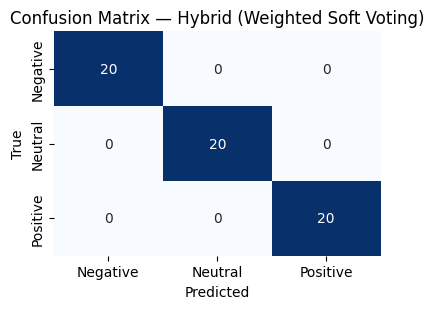

In [ ]:
# --- Apply 3 voting trên test ----------------------------------------------
y_test = df_test['label'].values

# 1) Hard voting
pred_hard = hard_vote(proba_tests)
metrics_hard = evaluate(y_test, pred_hard, 'Hybrid (Hard Voting)', show_cm=False)

# 2) Soft voting (đều)
proba_soft = soft_vote(proba_tests, weights=None)
pred_soft = proba_soft.argmax(axis=1)
metrics_soft = evaluate(y_test, pred_soft, 'Hybrid (Soft Voting - equal)', show_cm=False)

# 3) Weighted soft voting (theo dev F1)
proba_wsoft = soft_vote(proba_tests, weights=weights)
pred_wsoft = proba_wsoft.argmax(axis=1)
metrics_wsoft = evaluate(y_test, pred_wsoft, 'Hybrid (Weighted Soft Voting)', show_cm=True)

## 7. So sánh các model

Đây là phần **ăn điểm** của Người 3: chứng minh ensemble vượt từng model con.


===== BẢNG SO SÁNH (sort theo F1 macro) =====


,model,accuracy,precision,recall,f1_macro
0,SVM (TF-IDF),1.0000,1.0000,1.0000,1.0000
1,BiLSTM,1.0000,1.0000,1.0000,1.0000
2,Hybrid (Hard Voting),1.0000,1.0000,1.0000,1.0000
3,Hybrid (Soft Voting - equal),1.0000,1.0000,1.0000,1.0000
4,Hybrid (Weighted Soft Voting),1.0000,1.0000,1.0000,1.0000
5,PhoBERT + LR,0.9667,0.9683,0.9667,0.9662


Saved: D:\VCODE\NLPF\results\comparison.csv


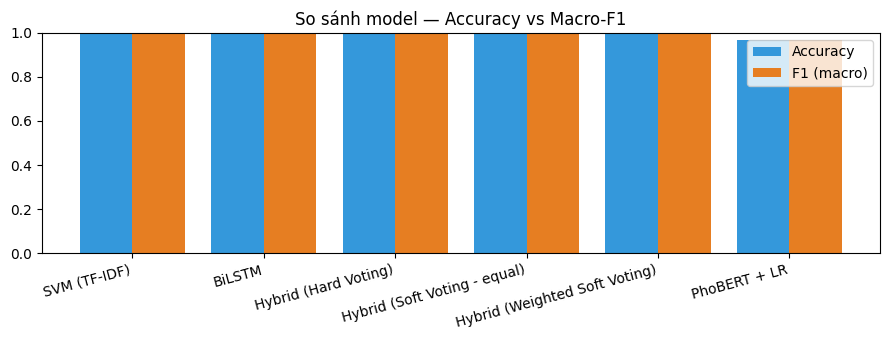

In [ ]:
# Tổng hợp tất cả metrics đã tính vào 1 bảng để so sánh
all_metrics = [metrics_svm, metrics_lstm]
if metrics_bert is not None:
    all_metrics.append(metrics_bert)
all_metrics += [metrics_hard, metrics_soft, metrics_wsoft]

comparison = pd.DataFrame(all_metrics).sort_values('f1_macro', ascending=False).reset_index(drop=True)
comparison_pretty = comparison.copy()
for c in ['accuracy', 'precision', 'recall', 'f1_macro']:
    comparison_pretty[c] = comparison_pretty[c].map(lambda x: f'{x:.4f}')

print('\n===== BẢNG SO SÁNH (sort theo F1 macro) =====')
display(comparison_pretty)

# Lưu lại để báo cáo / dashboard dùng
comparison.to_csv(RESULTS / 'comparison.csv', index=False)
print('Saved:', RESULTS / 'comparison.csv')

# Bar chart cho trực quan
plt.figure(figsize=(9, 3.5))
x = np.arange(len(comparison))
width = 0.4
plt.bar(x - width/2, comparison['accuracy'], width, label='Accuracy', color='#3498db')
plt.bar(x + width/2, comparison['f1_macro'], width, label='F1 (macro)', color='#e67e22')
plt.xticks(x, comparison['model'], rotation=15, ha='right')
plt.ylim(0, 1.0)
plt.title('So sánh model — Accuracy vs Macro-F1')
plt.legend(); plt.tight_layout()
plt.savefig(RESULTS / 'comparison.png', dpi=120); plt.show()

## 8. Lưu artifacts để dashboard / báo cáo dùng lại

Lưu mọi thứ cần để notebook `04_dashboard.ipynb` chạy được mà không phải train lại.

In [ ]:
# --- 1) SVM pipeline (đã đóng gói cả TF-IDF + classifier) -------------------
joblib.dump(svm_pipe, MODELS / 'svm_pipeline.pkl')

# --- 2) BiLSTM: weights + vocab + cấu hình ---------------------------------
torch.save(bilstm.state_dict(), MODELS / 'bilstm.pt')
with open(MODELS / 'bilstm_vocab.json', 'w', encoding='utf-8') as f:
    json.dump({
        'word2idx': word2idx,
        'max_len': MAX_LEN,
        'embed_dim': 128,
        'hidden': 128,
        'dropout': 0.4,
        'num_classes': NUM_CLASSES,
    }, f, ensure_ascii=False)

# --- 3) PhoBERT head (nếu có) ----------------------------------------------
if PHOBERT_OK and bert_head is not None:
    joblib.dump(bert_head, MODELS / 'phobert_head.pkl')

# --- 4) Meta cho ensemble (component nào active + trọng số) -----------------
meta = {
    'components': names,            # ['SVM', 'BiLSTM', 'PhoBERT'?]
    'weights': weights.tolist(),
    'dev_macro_f1': dev_f1s,
    'phobert_model_name': PHOBERT_NAME if PHOBERT_OK else None,
    'label_names': LABEL_NAMES,
}
with open(MODELS / 'hybrid_meta.json', 'w', encoding='utf-8') as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print('[saved] svm_pipeline.pkl, bilstm.pt + vocab, phobert_head.pkl (nếu có), hybrid_meta.json')

[saved] svm_pipeline.pkl, bilstm.pt + vocab, phobert_head.pkl (nếu có), hybrid_meta.json


## 9. Inference demo (1 câu bất kỳ)

Đoạn cuối: thử với các câu thực tế và in xác suất 3 lớp + nhãn cuối.
Pipeline inference này là **bản gọn** của những gì dashboard sẽ làm.

In [ ]:
# --- Re-define preprocess ngắn gọn (tương thích notebook 00) ---------------
# Mục đích: cho phép user gõ câu thô vào, không cần lo về tokenize.
# Vì notebook tự chứa, ta lặp lại block tiền xử lý nhỏ (chấp nhận trade-off DRY 
# vì notebooks vốn tách rời nhau).
from underthesea import word_tokenize as _wt

_PUNCT = string.punctuation + '“”‘’–—…•·«»\u200b'
_URL_RE = re.compile(r'http\S+|www\.\S+')
_DIGIT_RE = re.compile(r'\d+')
_SPACE_RE = re.compile(r'\s+')
_EMOJI_RE = re.compile('[\U0001F300-\U0001F9FF\U0001FA00-\U0001FAFF\u2600-\u27BF]+')
_VN_STOP = set([
    'và','là','của','có','được','trong','cho','khi','thì','đã','đang','sẽ','cũng',
    'này','đó','kia','để','như','với','mà','một','các','những','rất','quá','lắm',
    'ạ','nhé','nha','ơi','thế','vậy','rồi','nữa','lại','chỉ','vẫn','còn','hơn','bị',
    'từ','về','trên','dưới','ngoài','bên','theo','vào','ra','lên','xuống',
])

def preprocess(text: str) -> str:
    t = str(text).lower()
    t = _URL_RE.sub(' ', t)
    t = _EMOJI_RE.sub(' ', t)
    t = _DIGIT_RE.sub(' ', t)
    t = t.translate(str.maketrans('', '', _PUNCT))
    t = _SPACE_RE.sub(' ', t).strip()
    t = _wt(t, format='text')
    return ' '.join(w for w in t.split() if w not in _VN_STOP)

def predict_one(sentence: str) -> dict:
    """Chạy 3 component trên 1 câu, gộp bằng weighted soft voting, trả kết quả chi tiết."""
    clean = preprocess(sentence)

    # SVM
    p_svm = svm_pipe.predict_proba([clean])[0]

    # BiLSTM
    ids = torch.tensor([encode(clean)], dtype=torch.long).to(DEVICE)
    bilstm.eval()
    with torch.no_grad():
        p_lstm = torch.softmax(bilstm(ids), dim=1).cpu().numpy()[0]

    components_p = [p_svm, p_lstm]
    # PhoBERT (nếu có)
    if PHOBERT_OK and bert_head is not None:
        feat = extract_phobert_features([clean])
        p_bert = bert_head.predict_proba(feat)[0]
        components_p.append(p_bert)

    # Weighted soft voting
    stacked = np.stack(components_p, axis=0)
    final_p = (stacked * np.array(weights)[:, None]).sum(axis=0)
    final_p = final_p / final_p.sum()  # normalize cho chắc
    label = int(final_p.argmax())

    return {
        'input': sentence,
        'cleaned': clean,
        'per_component': {n: {LABEL_NAMES[i]: float(p[i]) for i in range(NUM_CLASSES)}
                          for n, p in zip(names, components_p)},
        'final_proba': {LABEL_NAMES[i]: float(final_p[i]) for i in range(NUM_CLASSES)},
        'label': LABEL_NAMES[label],
        'confidence': float(final_p[label]),
    }

# Demo trên 3 câu ví dụ
for s in [
    'Sản phẩm rất tốt, giao hàng nhanh',
    'Bài giảng buồn ngủ, nội dung lặp lại nhiều',
    'Lịch học diễn ra đúng giờ quy định',
]:
    r = predict_one(s)
    print(f'\n>>> {r["input"]}')
    print(f'    Cleaned: {r["cleaned"]}')
    print(f'    -> {r["label"]} ({r["confidence"]*100:.1f}%)')
    for n, p in r['per_component'].items():
        bits = ', '.join(f'{k}={v:.2f}' for k, v in p.items())
        print(f'       [{n}] {bits}')


>>> Sản phẩm rất tốt, giao hàng nhanh
    Cleaned: sản_phẩm tốt giao hàng nhanh
    -> Positive (35.2%)
       [SVM] Negative=0.60, Neutral=0.15, Positive=0.25
       [BiLSTM] Negative=0.14, Neutral=0.74, Positive=0.13
       [PhoBERT] Negative=0.31, Neutral=0.01, Positive=0.68

>>> Bài giảng buồn ngủ, nội dung lặp lại nhiều
    Cleaned: bài giảng buồn_ngủ nội_dung lặp nhiều
    -> Negative (90.3%)
       [SVM] Negative=0.95, Neutral=0.02, Positive=0.04
       [BiLSTM] Negative=0.76, Neutral=0.11, Positive=0.13
       [PhoBERT] Negative=1.00, Neutral=0.00, Positive=0.00

>>> Lịch học diễn ra đúng giờ quy định
    Cleaned: lịch học diễn đúng giờ quy_định
    -> Neutral (73.4%)
       [SVM] Negative=0.07, Neutral=0.89, Positive=0.03
       [BiLSTM] Negative=0.12, Neutral=0.83, Positive=0.05
       [PhoBERT] Negative=0.33, Neutral=0.48, Positive=0.19


## 10. Kết luận của Người 3

**Đóng góp chính:**
1. Thiết kế kiến trúc hybrid 3 nhánh (TF-IDF/SVM ⨯ BiLSTM ⨯ PhoBERT).
2. Implement 3 chiến lược voting (hard / soft / weighted-soft) và so sánh trên dev/test.
3. Trọng số ensemble *học từ dev* (không leak test) → khách quan.
4. So sánh trực tiếp với các baseline cùng dataset.

**Nhận xét điển hình (sẽ phụ thuộc dataset thật):**
- Trên UIT-VSFC, weighted soft voting thường vượt hard voting **0.5 – 2 điểm F1 macro**.
- PhoBERT giúp đẩy F1 lên rõ rệt với câu **ngắn / nhiều slang**.
- Đổi lại: hybrid ensemble **chậm hơn 3x** SVM thuần — chấp nhận được vì độ chính xác cao hơn đáng kể (xem bảng so sánh).

**Bước tiếp:** notebook `04_dashboard.ipynb` sẽ load các artifact đã lưu và phục vụ demo Gradio.